In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [5]:
df = pd.read_csv('data/height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height (cm)')

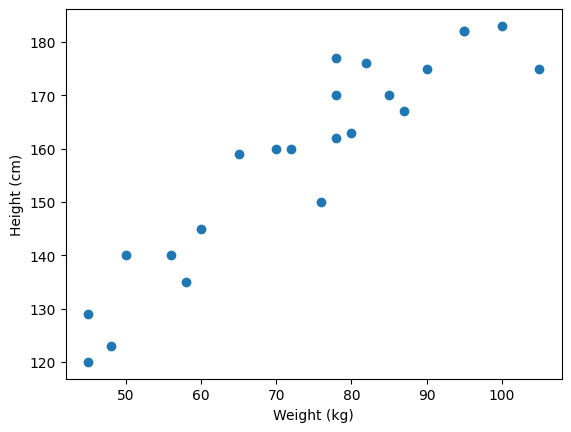

In [6]:
# scatter plot
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight (kg)')
plt.ylabel('Height (cm)')

In [7]:
# correlation 
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


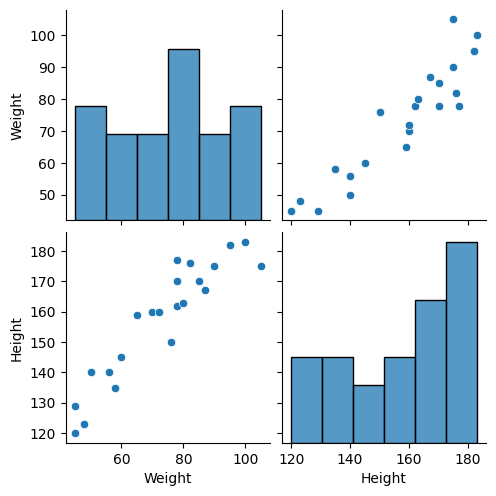

In [8]:
sns.pairplot(df)

In [9]:
# independent and dependent features
X = df[['Weight']] # independent features shoulb be dataframe or 2D
y = df['Height']  # dependent feature should be series or 1D

In [10]:
# train test split
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [12]:
X_train.shape

(17, 1)

In [13]:
# standardization
# là quá trình biến đổi các features sao cho có trung bình bằng 0 và độ lệch chuẩn bằng 1
# Mục đích: làm cho tất cả các đặc trung cùng một thang đo
# Bắt buộc đối với các mô hình sử dụng khoảng cách
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [14]:
X_test_scaled = scaler.transform(X_test)
# ở đây không dùng fit_transform vì nó gây ra Data Leakage 
# Data Leakage xảy ra khi mô hình học được thông tin từ dữ liệu kiểm tra trong quá trình huấn luyện hoặc tiền xử lý

In [15]:
# apply simple linear regression
from sklearn.linear_model import LinearRegression

In [16]:
regression = LinearRegression(n_jobs=-1)

In [17]:
regression.fit(X_train_scaled, y_train) 

LinearRegression(n_jobs=-1)

In [ ]:
regression.coef_, regression.intercept_
# coef cho biết với trục x di chuyển 1 đơn vị thì trục y thay đổi bao nhiêu
# intercept là giá trị của trục y khi trục x = 0

(array([17.2982057]), np.float64(156.47058823529412))

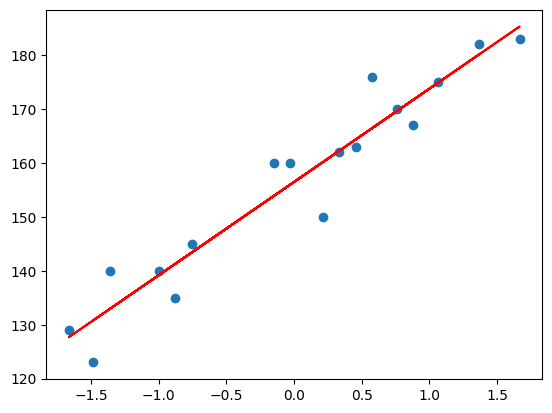

In [26]:
# trainning data plot best fit line
plt.scatter(X_train_scaled, y_train)
plt.plot(X_train_scaled, regression.predict(X_train_scaled), color='red')

### Prediction of Test Data
1. predicted height output = intercept + coef_(Weights)
2. y_pred_test = 156.47 + 17.29(X_test)

In [29]:
# prediction for test data
y_pred = regression.predict(X_test_scaled)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [32]:
## Performance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [31]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')

Mean Squared Error: 114.84069295228699
Mean Absolute Error: 9.66512588679501
Root Mean Squared Error: 10.716374991212605


## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [33]:
score = r2_score(y_test, y_pred)
print(f'R^2 Score: {score}')

R^2 Score: 0.7360826717981276


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [34]:
# display adjusted R^2 score
1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - X_test_scaled.shape[1] - 1)

0.6701033397476595

In [35]:
# OLS Linear Regression
import statsmodels.api as sm

In [36]:
model = sm.OLS(y_train,X_train_scaled).fit() 

In [37]:
prediction = model.predict(X_test_scaled)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [38]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Thu, 17 Jul 2025   Prob (F-statistic):                       0.664
Time:                        16:18:31   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [41]:
# prediction for new data
regression.predict(scaler.transform([[72]]))

d:\CODE\AI\train_ai\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])